<a href="https://colab.research.google.com/github/iaportnov/gp4_statistics_huistics/blob/main/gp4_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [150]:
# Основа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Статистика
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

# Часть 1.

In [121]:
# !wget https://raw.githubusercontent.com/iaportnov/gp4_statistics_huistics/refs/heads/main/data_ab.csv

Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).

По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



In [122]:
df = pd.read_csv('data_ab.csv')

In [123]:
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


Всего у нас 294478 записей

In [124]:
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


Изначально у нас 147202 пользователя в контрольной группе и 147276 пользователей в тестовой.

In [125]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [126]:
df['date'] = df['timestamp'].dt.strftime('%Y-%m-%d')
del df['timestamp']

In [127]:
df.date.value_counts().sort_index()

,count
date,
2025-01-02,5783
2025-01-03,13394
2025-01-04,13284
2025-01-05,13124
2025-01-06,13528
2025-01-07,13381
2025-01-08,13564
2025-01-09,13439
2025-01-10,13523


Наш эксперимент шел 23 дня, при этом первый день (2025-01-02) и последний день (2025-01-24) имеют меньше записей, скорее всего тест запустили и закончили в середине соответствующих дней, поэтому в эти даты не получилось набрать соразмерную с другими днями выборку.

<Axes: xlabel='date'>

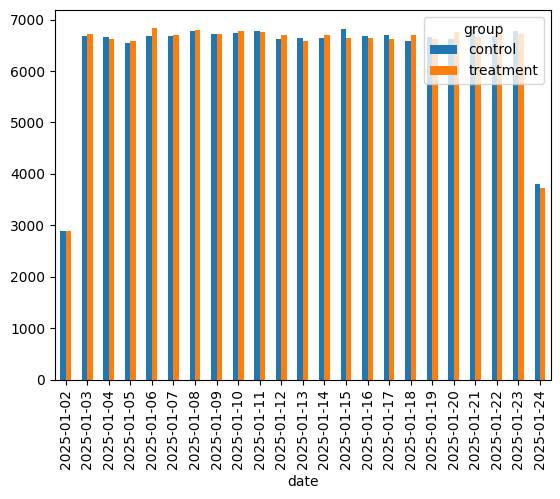

In [128]:
df.groupby(['date','group'])['user_id'].count().unstack().plot(kind='bar')

Тестовая и контрольная выборка распределена по дням почти одинаково.

## Чистим данные от дубликатов и несостыковок

In [129]:
df['user_id'].value_counts()

,count
user_id,
752737,2
781280,2
767913,2
886060,2
731779,2
...,...
653383,1
732573,1
867433,1


Есть пользователи, которые попали в тест дважды, так не должно быть

In [130]:
df[df.duplicated('user_id', keep=False)].sort_values('user_id')

,user_id,group,landing_page,converted,date
213114,630052,treatment,old_page,1,2025-01-07
230259,630052,treatment,new_page,0,2025-01-17
251762,630126,treatment,new_page,0,2025-01-19
22513,630126,treatment,old_page,0,2025-01-14
11792,630137,control,new_page,0,2025-01-22
...,...,...,...,...,...
99479,945703,control,old_page,0,2025-01-18
186960,945797,control,old_page,0,2025-01-13
40370,945797,control,new_page,1,2025-01-11
165143,945971,control,old_page,0,2025-01-16


Интересно, некоторые пользователи видели несколько версий лэндинга, хотя принадлежат к одной группе (control или treatment). Так не должно быть, так как пользователь может действовать иначе заходе на старую страницу, после того как до этого он был на новой, например он такой подумал:

> хмммм, бля, я тут кнопку жмал, а кнопки теперь нет, хуйня не буду ничего искать

Таких пользователей нужно либо удалить, либо оставить их первое взаимодействие.

Тех пользователей, кто относится к какой-то из групп, при этом первой увидел сайт для другой группы следует выкинуть из выборки.


In [131]:
new_page_df = df[df['landing_page']=='new_page']
new_page_df[new_page_df.duplicated('user_id', keep=False)].sort_values('user_id')

,user_id,group,landing_page,converted,date
114320,630887,treatment,new_page,0,2025-01-22
28177,630887,control,new_page,0,2025-01-07
39018,631838,control,new_page,0,2025-01-21
145226,631838,treatment,new_page,0,2025-01-09
121799,632464,treatment,new_page,0,2025-01-06
...,...,...,...,...,...
63432,945125,treatment,new_page,0,2025-01-14
183169,945387,treatment,new_page,0,2025-01-03
275158,945387,control,new_page,0,2025-01-20
243428,945627,treatment,new_page,1,2025-01-17


Хах, оказывается есть такие пользователи, которые попали и в тест, и в контроль, оставим их группу из первой интеракции, если вид сайта совпадает с нужной для группы.

In [132]:
df = df.sort_values(['user_id','date']).drop_duplicates('user_id', keep='first')

In [133]:
df = df[((df['group']=='control') & (df['landing_page']=='old_page')) | ((df['group']=='treatment') & (df['landing_page']=='new_page'))]

In [134]:
df[df.duplicated('user_id', keep=False)].sort_values('user_id')

,user_id,group,landing_page,converted,date


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288629 entries, 63114 to 237031
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       288629 non-null  int64 
 1   group         288629 non-null  object
 2   landing_page  288629 non-null  object
 3   converted     288629 non-null  int64 
 4   date          288629 non-null  object
dtypes: int64(2), object(3)
memory usage: 13.2+ MB


ВСЕ! Теперь для каждого пользователя хранится только первая интеракция и у всех группа соответствует версии сайта.

Убрали около 6к записей.

<Axes: xlabel='date'>

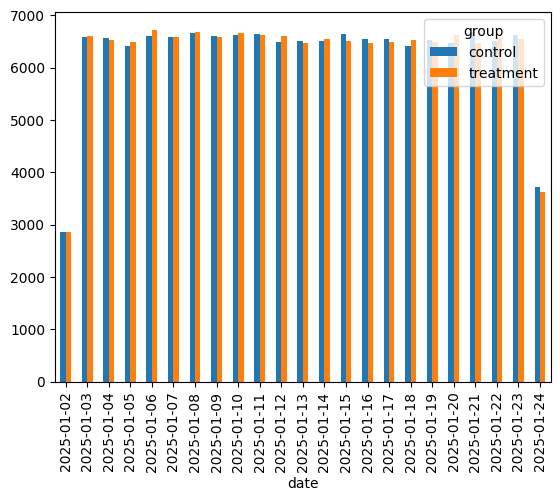

In [136]:
df.groupby(['date','group'])['user_id'].count().unstack().plot(kind='bar')

Можем заметить, что убранные значения почти не повлияли на распределение пользователей в группах.

## Выбираем метрику и строим гипотезы

Сразу обозначим основную метрику для нашего теста:

**Конверсия (в целевое действие) на сайте.**

In [137]:
df.groupby(['date','group']).agg({'converted':'mean'}).unstack()

converted          
group        control treatment
date                          
2025-01-02  0.125568  0.119874
2025-01-03  0.113692  0.113849
2025-01-04  0.121955  0.116656
2025-01-05  0.123518  0.115219
2025-01-06  0.115221  0.123086
2025-01-07  0.120918  0.116254
2025-01-08  0.119112  0.120886
2025-01-09  0.119545  0.118531
2025-01-10  0.113088  0.126444
2025-01-11  0.118761  0.115518
2025-01-12  0.122263  0.121874
2025-01-13  0.117087  0.111231
2025-01-14  0.126288  0.119982
2025-01-15  0.120337  0.113263
2025-01-16  0.122000  0.119191
2025-01-17  0.123013  0.126695
2025-01-18  0.124494  0.123795
2025-01-19  0.120264  0.116031
2025-01-20  0.114498  0.117994
2025-01-21  0.125786  0.116049
2025-01-22  0.119330  0.117638
2025-01-23  0.126603  0.120874
2025-01-24  0.117900  0.119835

Смотря на разные дни, мы можем видеть как то старая, то новая версии побеждают по конверсии, но мы не собираемся запускать по понедельникам новую версию сайта, а по субботам старую, так что мы не будем брать конверсии по дням, потому что их рассмотрение не показывает общей картины: стал ли новый лендинг лучше или нет. Сосредоточимся на конверсии по тестовой и контрольной выборкам за все время эксперимента.

In [139]:
df.groupby(['group']).agg({'converted':'mean'})

,converted
group,
control,0.120403
treatment,0.118693


Как будто стало хуже, но не отчаиваемся, не мы же фичу пилили 🥰

Ну исходя из нашей метрики обозначим гипотезы:

H0 – показатели конверсии в целевое действие на старой и новой версии сайта не отличаются.

H1 – показатели конверсии в целевое действие на старой и новой версии сайта различны.

Мы решили взять двухстороннюю гипотезу. Это позволит нам проверить, стал ли новый сайт хуже.

Зачем это нужно: могло ведь быть такое, что компания выкатила бы новую версию сайта на всех, даже если бы конверсия не была выше (в целях развития и добавления в дальнейшем других функций, например), но если мы бы рассматривали одностороннюю гипотезу (конверсия на новой версии, выше чем на старой), то мы бы не заметили негативного эффекта перехода на новую версию. Короче говоря, лучше перестраховаться, да и с двухсторонней гипотезой можно получить больше информации для дальнейших действий.

## Смотрим на однородность выборок

Но перед тем, как приступить к подсчету a/b-теста, нам необходимо убедиться, что изначально тест бы спроектирован правильно.

Круто будет посмотреть на то, что пользователи в случайных выборках по дням ведут себя одинаково. Для этого проведем a/a тест на контрольной выборке, фиксируем уровень значимости в 5%, поэтому мы ожидаем, что на 5% наблюдений будут заметны стат. значимые отличия. На тестовой выборке исследование проводить не будем, так как природа данных может быть другая и не факт, что выборки будут однородными.

In [84]:
def aa_test_func(sample, n_iter=10000):
  results = []
  rng = np.random.default_rng(seed = 67)
  values = sample['converted'].values.copy()
  n = values.shape[0]
  for i in range(n_iter):
    shuffled = rng.permutation(values)
    s1, s2 = shuffled[:n//2], shuffled[n//2:]
    try:
      pval = proportions_ztest([np.sum(s1), np.sum(s2)], [n//2, n - n//2])[1]
    except:
      pval = 1
    results.append(pval)
  results = np.array(results)
  return results[results < 0.05].shape[0] / n_iter

In [141]:
df_control = df[df['group']=='control']
result_dict = {}
for date in sorted(df_control['date'].unique()):
  result_dict[date] = aa_test_func(df_control[df_control['date']==date])
result_dict

{'2025-01-02': 0.0569,
 '2025-01-03': 0.0521,
 '2025-01-04': 0.0516,
 '2025-01-05': 0.0517,
 '2025-01-06': 0.0496,
 '2025-01-07': 0.0547,
 '2025-01-08': 0.0532,
 '2025-01-09': 0.0485,
 '2025-01-10': 0.0481,
 '2025-01-11': 0.0549,
 '2025-01-12': 0.0463,
 '2025-01-13': 0.0494,
 '2025-01-14': 0.0543,
 '2025-01-15': 0.0541,
 '2025-01-16': 0.049,
 '2025-01-17': 0.0499,
 '2025-01-18': 0.0513,
 '2025-01-19': 0.0529,
 '2025-01-20': 0.0475,
 '2025-01-21': 0.0512,
 '2025-01-22': 0.0486,
 '2025-01-23': 0.05,
 '2025-01-24': 0.0532}

На 10000 итерациях мы получили количество ложноположительных тестов от 4,63% до 5,69%, что близко к ожидаемому в 5%. Поэтому, можем сказать, что изначальная сплитовалка (которую компания применила перед ткестом) работает правильно. Дополнительно посмотрим, что на качество сплитовалки на всей выборке, а не по дням.

In [86]:
aa_test_func(df_control)

0.0475

Тоже около 5%: чудесно, прелестно, замурчательно, можем уже переходить к a/b-тесту.

## Ну с параметрами остальнось поиграться

TODO EBAT

## Проверяем гипотезы

Ну что, приступим к подсчету a/b-теста.



In [153]:
df_control = df[df['group']=='control']
df_test = df[df['group']=='treatment']

In [147]:
control_conv, test_conv = df_control['converted'].sum(), df_test['converted'].sum()
control_size, test_size = df_control.shape[0], df_test.shape[0]

### **Основной тест - z-test для двух долей**

Подходит потому что основная метрика - конверсия - бинарный признак, следовательно сравниваются именно конверсии.

Плюсы:
* стандартный тест для A/B тестирования
* хорошо работает на больших выборках
* быстро вычисляется
* легко интерпретируется

Минусы:
* использует нормальное приближение;
* требует независимости наблюдений;
* хуже работает на маленьких выборках.

In [148]:
z_score, p_value = proportions_ztest([control_conv, test_conv], [control_size, test_size])

In [149]:
z_score, p_value

(np.float64(1.415922060808146), np.float64(0.1567983250879775))

p-value = 0.1568, при обозначенном нами уровне значимости в 0.05, мы говорим, что не можем отвергнуть нулевую гипотезу.

При этом z_score положительный, что говорит о том, что конверсия в контрольной группе была выше, но не стат. значимо.

### **Дополнительный тест — хи-квадрат-test**

Подходит нам тк проверяет зависимость между группой пользователя и фактом конверсии (обе переменные являются категориавльными)

Плюсы:

* хорошо подходит для категориальных данных
* устойчив на больших выборках
* классический статистический подход

Минусы:

* хуже интерпретируется бизнесово
* не показывает размер эффекта
* менее удобен для анализа uplift

Используем его как дополнительный в качестве подтверждения результата различия конверсия.

In [151]:
table = [[control_conv, control_size - control_conv],
          [test_conv, test_size - test_conv]]

chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(1.9886211130351608), pvalue=np.float64(0.15848512880276133), dof=1, expected_freq=array([[ 17251.60339051, 127055.39660949],
       [ 17253.39660949, 127068.60339051]]))

В хи-квадрат тесте мы получили p-value = 0.1585, что близко к результату z-test, так что мы:

1.   убедились в отсутствии статзначимых отличий между двумя версиями сайта
2.   проверили, что z-test у нас работает корректно

Нулевую гипотезу мы не можем отвергнуть.

### **Bootstrap**

Кроме z-теста и хи-квадрат-теста используем bootstrap чтобы проверить устойчивость результата.

Используем именно бутстрап потому что в нашей задаче:

* выборка очень большая
* бинарная метрика хорошо подходит под z-test
* классические методы (z-test и chi-2) уже работают корректно

Плюсы:

* меньше зависит от предположений о распределении
* позволяет оценить uncertainty эффекта
* показывает доверительный интервал эффекта

Минусы:

* вычислительно тяжелее
* сложнее интерпретируется
* избыточен для простого A/B теста на большой выборке

In [165]:
def bootstrap_ab_func(control, test, n_iter=10000):
  diffs = []
  rng = np.random.default_rng(seed = 67)
  control_values = control['converted'].values.copy()
  test_values = test['converted'].values.copy()
  for i in range(n_iter):
    control_sample = rng.choice(control_values, control_values.shape[0], replace=True)
    test_sample = rng.choice(test_values, test_values.shape[0], replace=True)
    diffs.append(test_sample.mean() - control_sample.mean())
  return np.percentile(diffs, 2.5), np.percentile(diffs, 97.5) # по 0.025 с каждой стороны

In [166]:
bootstrap_ab_func(df_control, df_test)

(np.float64(-0.0041145433608928625), np.float64(0.0005977236914806406))

Ну вот: отбутстрапили 10к разочков, получили интервал от -0.004 до 0.0006, короче говоря, мы выкинули по 2.5% экстримальных значений слева и справа и увидели, что как минимум конверсия на новой версии сайта хуже на 0.4% и как максимум выше на 0.06%, в любом случае, так как 0 входит в интервал, мы говорим об отсутствии стат. значимых отличий и как итог не можем отвергнуть нулевую гипотезу.

В целом, все статистические тесты при наших параметрах не показали стат. значимых отличий между конверсиями на старой и новой версиях сайтов.